In [1]:
import pandas as pd
import numpy as np

# Make results reproducible
np.random.seed(42)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [3]:
# Number of customers
num_customers = 2000

customers = pd.DataFrame({
    "Customer_ID": [f"CUST{i:04d}" for i in range(1, num_customers + 1)],
    "Customer_Name": [f"Customer_{i}" for i in range(1, num_customers + 1)],
    "Gender": np.random.choice(
        ["Male", "Female"],
        num_customers,
        p=[0.55, 0.45]
    ),
    "Age": np.random.randint(18, 65, num_customers),
    "City": np.random.choice(
        ["Mumbai", "Delhi", "Bangalore", "Hyderabad",
         "Chennai", "Pune", "Kolkata", "Ahmedabad"],
        num_customers
    ),
    "Customer_Segment": np.random.choice(
        ["Consumer", "Corporate", "Home Office"],
        num_customers,
        p=[0.65, 0.20, 0.15]
    )
})

customers.head()

,Customer_ID,Customer_Name,Gender,Age,City,Customer_Segment
0,CUST0001,Customer_1,Male,45,Ahmedabad,Consumer
1,CUST0002,Customer_2,Female,24,Hyderabad,Consumer
2,CUST0003,Customer_3,Female,52,Delhi,Consumer
3,CUST0004,Customer_4,Female,45,Chennai,Consumer
4,CUST0005,Customer_5,Male,31,Hyderabad,Consumer


In [5]:
products = pd.DataFrame({
    "Product_ID": [f"PROD{i:03d}" for i in range(1, 101)],
    "Product_Name": [f"Product_{i}" for i in range(1, 101)],
    "Category": np.random.choice(
        ["Electronics", "Furniture", "Clothing", "Home & Kitchen"],
        100
    ),
    "Sub_Category": np.random.choice(
        ["Laptop", "Mobile", "Chair", "Table",
         "Shirt", "Shoes", "Kitchen", "Accessories"],
        100
    ),
    "Brand": np.random.choice(
        ["Brand A", "Brand B", "Brand C", "Brand D", "Brand E"],
        100
    ),
    "Cost_Price": np.random.randint(500, 50000, 100)
})

products.head()

,Product_ID,Product_Name,Category,Sub_Category,Brand,Cost_Price
0,PROD001,Product_1,Electronics,Laptop,Brand D,19397
1,PROD002,Product_2,Home & Kitchen,Accessories,Brand E,8668
2,PROD003,Product_3,Furniture,Shoes,Brand C,7361
3,PROD004,Product_4,Clothing,Mobile,Brand C,42258
4,PROD005,Product_5,Furniture,Table,Brand B,14250


In [7]:
num_orders = 10000

orders = pd.DataFrame({
    "Order_ID": [f"ORD{i:05d}" for i in range(1, num_orders + 1)],
    "Order_Date": pd.to_datetime(
        np.random.choice(
            pd.date_range("2023-01-01", "2025-12-31"),
            num_orders
        )
    ),
    "Customer_ID": np.random.choice(
        customers["Customer_ID"],
        num_orders
    ),
    "Product_ID": np.random.choice(
        products["Product_ID"],
        num_orders
    ),
    "Quantity": np.random.randint(1, 6, num_orders),
    "Discount": np.round(
        np.random.uniform(0, 0.30, num_orders),
        2
    ),
    "Payment_Method": np.random.choice(
        ["Credit Card", "Debit Card", "UPI", "Cash on Delivery"],
        num_orders
    )
})

orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Payment_Method
0,ORD00001,2023-11-17,CUST0545,PROD071,3,0.05,Debit Card
1,ORD00002,2024-01-25,CUST0712,PROD076,2,0.18,Debit Card
2,ORD00003,2024-03-09,CUST1258,PROD019,2,0.00,UPI
3,ORD00004,2025-11-11,CUST1050,PROD027,4,0.24,Debit Card
4,ORD00005,2025-05-22,CUST1578,PROD018,1,0.27,Cash on Delivery


In [9]:
# Merge product cost into orders
orders = orders.merge(
    products[["Product_ID", "Cost_Price"]],
    on="Product_ID",
    how="left"
)

# Create selling price
orders["Unit_Price"] = (
    orders["Cost_Price"] * np.random.uniform(1.15, 1.60, num_orders)
).round(2)

# Calculate sales after discount
orders["Sales"] = (
    orders["Quantity"]
    * orders["Unit_Price"]
    * (1 - orders["Discount"])
).round(2)

# Calculate profit
orders["Profit"] = (
    orders["Sales"]
    - (orders["Quantity"] * orders["Cost_Price"])
).round(2)

orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Payment_Method,Cost_Price,Unit_Price,Sales,Profit
0,ORD00001,2023-11-17,CUST0545,PROD071,3,0.05,Debit Card,43519,57837.38,164836.53,34279.53
1,ORD00002,2024-01-25,CUST0712,PROD076,2,0.18,Debit Card,19739,31328.52,51378.77,11900.77
2,ORD00003,2024-03-09,CUST1258,PROD019,2,0.00,UPI,26105,33829.88,67659.76,15449.76
3,ORD00004,2025-11-11,CUST1050,PROD027,4,0.24,Debit Card,33194,42060.33,127863.40,-4912.60
4,ORD00005,2025-05-22,CUST1578,PROD018,1,0.27,Cash on Delivery,34967,55784.96,40723.02,5756.02


In [11]:
region_mapping = {
    "Mumbai": "West",
    "Delhi": "North",
    "Bangalore": "South",
    "Hyderabad": "South",
    "Chennai": "South",
    "Pune": "West",
    "Kolkata": "East",
    "Ahmedabad": "West"
}

customers["Region"] = customers["City"].map(region_mapping)

customers.head()

,Customer_ID,Customer_Name,Gender,Age,City,Customer_Segment,Region
0,CUST0001,Customer_1,Male,45,Ahmedabad,Consumer,West
1,CUST0002,Customer_2,Female,24,Hyderabad,Consumer,South
2,CUST0003,Customer_3,Female,52,Delhi,Consumer,North
3,CUST0004,Customer_4,Female,45,Chennai,Consumer,South
4,CUST0005,Customer_5,Male,31,Hyderabad,Consumer,South


In [13]:
# Save datasets to the data folder
customers.to_csv("../data/customers.csv", index=False)
products.to_csv("../data/products.csv", index=False)
orders.to_csv("../data/orders.csv", index=False)

print("Datasets successfully created!")
print(f"Customers: {len(customers):,}")
print(f"Products: {len(products):,}")
print(f"Orders: {len(orders):,}")


Datasets successfully created!
Customers: 2,000
Products: 100
Orders: 10,000


In [15]:
#Python
import pandas as pd
import numpy as np

customers = pd.read_csv("../data/customers.csv")
products = pd.read_csv("../data/products.csv")
orders = pd.read_csv("../data/orders.csv")

print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)

Customers: (2000, 7)
Products: (100, 6)
Orders: (10000, 11)


In [17]:
customers.head()

,Customer_ID,Customer_Name,Gender,Age,City,Customer_Segment,Region
0,CUST0001,Customer_1,Male,45,Ahmedabad,Consumer,West
1,CUST0002,Customer_2,Female,24,Hyderabad,Consumer,South
2,CUST0003,Customer_3,Female,52,Delhi,Consumer,North
3,CUST0004,Customer_4,Female,45,Chennai,Consumer,South
4,CUST0005,Customer_5,Male,31,Hyderabad,Consumer,South


In [19]:
products.head()

,Product_ID,Product_Name,Category,Sub_Category,Brand,Cost_Price
0,PROD001,Product_1,Electronics,Laptop,Brand D,19397
1,PROD002,Product_2,Home & Kitchen,Accessories,Brand E,8668
2,PROD003,Product_3,Furniture,Shoes,Brand C,7361
3,PROD004,Product_4,Clothing,Mobile,Brand C,42258
4,PROD005,Product_5,Furniture,Table,Brand B,14250


In [21]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Payment_Method,Cost_Price,Unit_Price,Sales,Profit
0,ORD00001,2023-11-17,CUST0545,PROD071,3,0.05,Debit Card,43519,57837.38,164836.53,34279.53
1,ORD00002,2024-01-25,CUST0712,PROD076,2,0.18,Debit Card,19739,31328.52,51378.77,11900.77
2,ORD00003,2024-03-09,CUST1258,PROD019,2,0.00,UPI,26105,33829.88,67659.76,15449.76
3,ORD00004,2025-11-11,CUST1050,PROD027,4,0.24,Debit Card,33194,42060.33,127863.40,-4912.60
4,ORD00005,2025-05-22,CUST1578,PROD018,1,0.27,Cash on Delivery,34967,55784.96,40723.02,5756.02


In [23]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        10000 non-null  object 
 1   Order_Date      10000 non-null  object 
 2   Customer_ID     10000 non-null  object 
 3   Product_ID      10000 non-null  object 
 4   Quantity        10000 non-null  int64  
 5   Discount        10000 non-null  float64
 6   Payment_Method  10000 non-null  object 
 7   Cost_Price      10000 non-null  int64  
 8   Unit_Price      10000 non-null  float64
 9   Sales           10000 non-null  float64
 10  Profit          10000 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 859.5+ KB


In [25]:
orders["Order_Date"] = pd.to_datetime(orders["Order_Date"])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        10000 non-null  object        
 1   Order_Date      10000 non-null  datetime64[ns]
 2   Customer_ID     10000 non-null  object        
 3   Product_ID      10000 non-null  object        
 4   Quantity        10000 non-null  int64         
 5   Discount        10000 non-null  float64       
 6   Payment_Method  10000 non-null  object        
 7   Cost_Price      10000 non-null  int64         
 8   Unit_Price      10000 non-null  float64       
 9   Sales           10000 non-null  float64       
 10  Profit          10000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(4)
memory usage: 859.5+ KB


In [27]:
print("CUSTOMERS")
print(customers.isnull().sum())

print("\nPRODUCTS")
print(products.isnull().sum())

print("\nORDERS")
print(orders.isnull().sum())

CUSTOMERS
Customer_ID         0
Customer_Name       0
Gender              0
Age                 0
City                0
Customer_Segment    0
Region              0
dtype: int64

PRODUCTS
Product_ID      0
Product_Name    0
Category        0
Sub_Category    0
Brand           0
Cost_Price      0
dtype: int64

ORDERS
Order_ID          0
Order_Date        0
Customer_ID       0
Product_ID        0
Quantity          0
Discount          0
Payment_Method    0
Cost_Price        0
Unit_Price        0
Sales             0
Profit            0
dtype: int64


In [29]:
print("Customer duplicates:", customers.duplicated().sum())
print("Product duplicates:", products.duplicated().sum())
print("Order duplicates:", orders.duplicated().sum())

Customer duplicates: 0
Product duplicates: 0
Order duplicates: 0


In [31]:
orders[[
    "Quantity",
    "Discount",
    "Cost_Price",
    "Unit_Price",
    "Sales",
    "Profit"
]].describe()

,Quantity,Discount,Cost_Price,Unit_Price,Sales,Profit
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.994300,0.150539,24850.376400,34205.014669,87224.816335,12556.392435
std,1.403661,0.086878,14814.100633,20708.617740,72311.256273,18433.015482
min,1.000000,0.000000,900.000000,1035.050000,837.020000,-35116.750000
25%,2.000000,0.080000,11294.000000,16130.280000,29494.330000,1083.505000
50%,3.000000,0.150000,24730.000000,33891.595000,66800.760000,6658.155000
75%,4.000000,0.230000,37566.000000,51937.992500,129395.330000,18602.995000
max,5.000000,0.300000,49377.000000,78890.530000,382024.120000,135139.120000


In [33]:
total_sales = orders["Sales"].sum()

print(f"Total Sales: ₹{total_sales:,.2f}")

Total Sales: ₹872,248,163.35


In [35]:
total_profit = orders["Profit"].sum()

print(f"Total Profit: ₹{total_profit:,.2f}")

Total Profit: ₹125,563,924.35


In [37]:
total_orders = orders["Order_ID"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 10,000


In [39]:
average_order_value = orders["Sales"].sum() / orders["Order_ID"].nunique()

print(f"Average Order Value: ₹{average_order_value:,.2f}")

Average Order Value: ₹87,224.82


In [41]:
orders_customer = orders.merge(
    customers[["Customer_ID", "City", "Region", "Customer_Segment"]],
    on="Customer_ID",
    how="left"
)

In [43]:
region_sales = (
    orders_customer
    .groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
South    3.306945e+08
West     3.207882e+08
East     1.224762e+08
North    9.828916e+07
Name: Sales, dtype: float64

In [45]:
#sales by product


In [47]:
orders_full = orders_customer.merge(
    products[[
        "Product_ID",
        "Product_Name",
        "Category",
        "Sub_Category",
        "Brand"
    ]],
    on="Product_ID",
    how="left"
)

In [49]:
category_sales = (
    orders_full
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Home & Kitchen    2.804426e+08
Furniture         2.243993e+08
Clothing          1.971428e+08
Electronics       1.702634e+08
Name: Sales, dtype: float64

In [51]:
#monthly sales trend
orders_full["Year_Month"] = orders_full["Order_Date"].dt.to_period("M")

monthly_sales = (
    orders_full
    .groupby("Year_Month")["Sales"]
    .sum()
)

monthly_sales

Year_Month
2023-01    23282551.31
2023-02    22258998.86
2023-03    28069349.98
2023-04    21050864.17
2023-05    22516571.99
2023-06    22605725.25
2023-07    23968461.46
2023-08    23562383.27
2023-09    25035072.47
2023-10    26464458.51
2023-11    23156552.22
2023-12    21415362.74
2024-01    25890430.86
2024-02    22486242.53
2024-03    25393877.14
2024-04    21136750.09
2024-05    22015854.62
2024-06    24125476.66
2024-07    25431181.61
2024-08    26962145.98
2024-09    24597036.45
2024-10    21997154.71
2024-11    24053918.15
2024-12    27288313.10
2025-01    27421235.04
2025-02    22278373.18
2025-03    26905443.52
2025-04    26734474.82
2025-05    27946254.22
2025-06    20562534.80
2025-07    25122718.31
2025-08    23824113.14
2025-09    26751234.61
2025-10    20766454.35
2025-11    24140325.16
2025-12    25030268.07
Freq: M, Name: Sales, dtype: float64

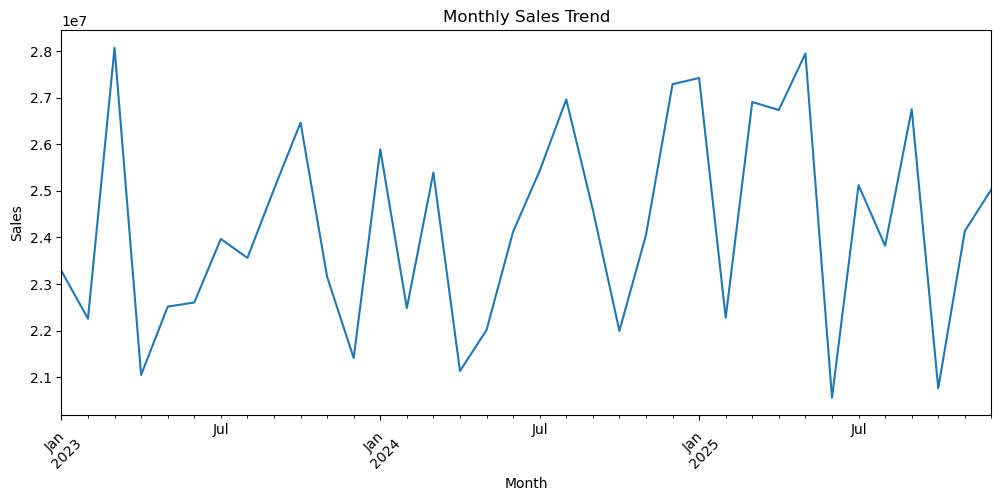

In [53]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", figsize=(12, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()